# 05 — Feature Engineering (Stage 2)

## Goal
Take the raw cleaned features from `data/03.cleaned/ac_cleaned.parquet`, engineer the
6 features we identified as missing in the baseline, and show the cumulative lift
on a re-trained `LinearRegression` before saving the engineered dataset for Stage 3+.

## Baseline (Stage 1.5) — the "before"
- Test R² = 0.471, MAE = ₹5,255
- Failure modes:
  1. Heteroscedasticity (fan shape in residuals)
  2. Brand premium modeled as additive shift, not multiplicative
  3. Brand × capacity interaction missing — 1.0T spans 3× price range
  4. Inverter × star_rating undervalued
  5. `model_year` imputed with global median, losing brand signal
  6. Multicollinear smart-feature flags (Wi-Fi ↔ APP r=0.99)

## The 6 engineering targets

| # | Target | What it fixes |
|---|---|---|
| 1 | `log_price` target | Heteroscedasticity + multiplicative brand premium |
| 2 | `smart_features = Wi-Fi + APP + Voice` | Multicollinearity |
| 3 | `age = 2026 - model_year` (brand-median imputation) | Throwaway 16% of model_year signal |
| 4 | Brand target encoding (K-fold smoothed) | Brand premium as flat shift is wrong |
| 5 | `inverter × star_rating` interaction | Undervalued combo in worst-10 |
| 6 | `is_window_ac` flag (capacity < 1.0) | Window AC pricing differs from split |

(Drop low-signal features deferred to Stage 3 — feature importance will tell us.)

## What this notebook does NOT do
- Tune hyperparameters
- Try ridge / lasso / tree models
- Save a model artifact (that's Stage 3+)

It only builds features and re-trains the **same** LinearRegression to show lift.
Stage 3 will swap the model, not the features.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook')
import warnings
warnings.filterwarnings('ignore')


In [6]:
# ====================================================================
# Load cleaned data + record baseline for later comparison
# ====================================================================
# We're going to engineer features and re-train the same LinearRegression.
# To know if our engineering helped, we need the "before" numbers.

data = pd.read_parquet(
    'D:/Study/data_science/underpriced-listing-predictor/data/03.cleaned/ac_cleaned.parquet'
)

# Baseline numbers from 04.baseline_linear_model.ipynb (test set)
baseline_test_r2   = 0.471
baseline_test_rmse = 7493
baseline_test_mae  = 5255
baseline_test_gap  = 0.043  # train R² − test R², "generalization health"

# Where the engineered dataset will be saved (Stage 3 reads from here)
output_dir = Path('D:/Study/data_science/underpriced-listing-predictor/data/04.features')
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Loaded data shape: {data.shape}")
print()
print(f"Output directory: {output_dir}")
print()
print(f"Baseline (Stage 1.5) — the numbers we need to beat:")
print(f"  Test R²        : {baseline_test_r2:.4f}")
print(f"  Test RMSE      : ₹{baseline_test_rmse:,.0f}")
print(f"  Test MAE       : ₹{baseline_test_mae:,.0f}")
print(f"  Train-test gap : {baseline_test_gap:.4f}  (generalization health)")


Loaded data shape: (994, 22)

Output directory: D:\Study\data_science\underpriced-listing-predictor\data\04.features

Baseline (Stage 1.5) — the numbers we need to beat:
  Test R²        : 0.4710
  Test RMSE      : ₹7,493
  Test MAE       : ₹5,255
  Train-test gap : 0.0430  (generalization health)


In [19]:
# installing category_encoders library 
# %pip install category_encoders
from category_encoders import TargetEncoder

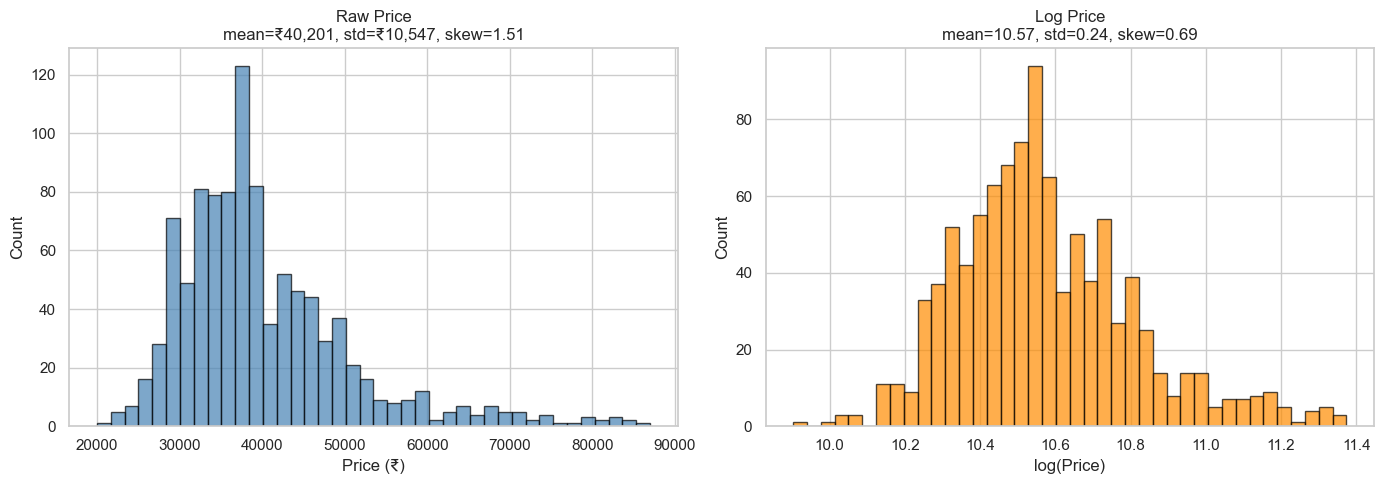

Distribution comparison:
  Raw price  : mean=₹   40,201   std=₹   10,547   skew= 1.51
  Log price  : mean=    10.57     std=     0.24     skew= 0.69


In [7]:
# ====================================================================
# Target 1/6: log_price — direct fix for heteroscedasticity
# ====================================================================
# Why: residuals vs predicted showed a fan shape (variance grows with
# predicted price). The root cause is that price is right-skewed — a
# few expensive ACs stretch the upper tail. Linear regression assumes
# constant variance, which is violated here.
#
# Fix: train on log(price) instead of price. Linear-on-log = exponential
# in real space. Heteroscedasticity disappears because the model is
# fitting proportional (multiplicative) error, not absolute error.
#
# Bonus: brand premiums become additive in log-space. log(80000) − log(40000)
# is the same increment no matter the base — exactly what our worst-10
# table showed was missing.

# Create log_price
data['log_price'] = np.log(data['price'])

# Show the distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data['price'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Count')
axes[0].set_title(
    f"Raw Price\n"
    f"mean=₹{data['price'].mean():,.0f}, std=₹{data['price'].std():,.0f}, "
    f"skew={data['price'].skew():.2f}"
)

axes[1].hist(data['log_price'], bins=40, edgecolor='black', alpha=0.7, color='darkorange')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Count')
axes[1].set_title(
    f"Log Price\n"
    f"mean={data['log_price'].mean():.2f}, std={data['log_price'].std():.2f}, "
    f"skew={data['log_price'].skew():.2f}"
)

plt.tight_layout()
plt.show()

# Quick comparison
print("Distribution comparison:")
print(f"  Raw price  : mean=₹{data['price'].mean():>9,.0f}   "
      f"std=₹{data['price'].std():>9,.0f}   skew={data['price'].skew():>5.2f}")
print(f"  Log price  : mean={data['log_price'].mean():>9.2f}     "
      f"std={data['log_price'].std():>9.2f}     skew={data['log_price'].skew():>5.2f}")


- skewness of 0.69 on log transformed prices shows that It has slight positive skew.
- Also the Prices are now sort-of normally distributed.
- It is not perfectly normal, since there are genuine premium brand products.

### ***Feature Engineer -> smart_features***

In [8]:
# ====================================================================
# Target 2/6: smart_features = Wi-Fi + APP + Voice
# ====================================================================
# Why: Wi-Fi, APP, and Voice flags have near-perfect correlation in EDA
# (Wi-Fi ↔ APP r=0.99, Voice r=0.80 with both). They are essentially
# the same underlying "smart" capability. Three columns add noise
# without adding signal to a linear model.
#
# Fix: collapse them into a single 'smart_features' count. The model
# now has one feature representing "how smart is this AC" (0–3) instead
# of three near-collinear booleans.

data['smart_features'] = (
    data['Wi-Fi Connectivity'] +
    data['APP Control'] +
    data['Voice Control']
)

# Distribution
print("smart_features distribution:")
print(data['smart_features'].value_counts().sort_index())
print()

# Sanity check: does the consolidation make sense?
# Cross-tab against one of the originals to confirm:
#   - smart_features=0 should have Wi-Fi=0 (no smart features at all)
#   - smart_features=3 should have Wi-Fi=1 (all three present)
#   - smart_features=1,2 can mix (some rows have just Wi-Fi, some have
#     Wi-Fi+APP without Voice, etc.)
print("Cross-tab: smart_features vs Wi-Fi Connectivity")
print(pd.crosstab(data['smart_features'], data['Wi-Fi Connectivity']))


smart_features distribution:
smart_features
0    813
1      2
2     54
3    125
Name: count, dtype: int64

Cross-tab: smart_features vs Wi-Fi Connectivity
Wi-Fi Connectivity    0    1
smart_features              
0                   813    0
1                     0    2
2                     0   54
3                     0  125


- Now we can drop these three Individual features

### ***Feature -> age***

In [16]:
# ====================================================================
# Target 3/6: age = 2026 - model_year, with brand-median imputation
# ====================================================================
# Why: model_year is 16.4% missing, and missingness is brand-concentrated
# (iMee 100%, Toshiba 100%, BPL 50%, O General 42%). The Stage 1.5
# baseline used GLOBAL median, which threw away brand signal.
#
# Fix:
#   1. Add a 'model_year_missing' indicator (1 if was missing, else 0)
#      — captures whether "year unknown" itself carries signal
#   2. Impute missing years with BRAND-MEDIAN (preserves brand signal)
#   3. Transform to age = 2026 - model_year (depreciation signal)

# Verify current missingness
print(f"model_year missing: {data['model_year'].isna().sum()} / {len(data)} "
      f"({data['model_year'].isna().mean()*100:.1f}%)")

# Convert to float so fillna() can accept the float brand medians
# (Int64 → float64; Int64 columns reject float fill values when NaN is present)
data['model_year'] = data['model_year'].astype('float64')

# Step 1: missingness indicator
data['model_year_missing'] = data['model_year'].isna().astype(int)

# Step 2: brand-median imputation
brand_medians = data.groupby('brand')['model_year'].transform('median')
data['model_year'] = data['model_year'].fillna(brand_medians)

# If any brand has ALL missing (median is NaN), fall back to global median
if data['model_year'].isna().any():
    global_median = data['model_year'].median()
    print(f"Warning: {data['model_year'].isna().sum()} rows still missing "
          f"after brand-median. Falling back to global median ({global_median:.0f})")
    data['model_year'] = data['model_year'].fillna(global_median)

# Step 3: transform to age
data['age'] = 2026 - data['model_year']

# Sanity check
print()
print(f"After imputation, model_year missing: {data['model_year'].isna().sum()}")
print()
print("age distribution:")
print(data['age'].describe())
print()
print("model_year_missing distribution:")
print(data['model_year_missing'].value_counts())


model_year missing: 163 / 994 (16.4%)

After imputation, model_year missing: 0

age distribution:
count    994.000000
mean       1.490946
std        1.337513
min        0.000000
25%        0.000000
50%        1.000000
75%        3.000000
max        8.000000
Name: age, dtype: float64

model_year_missing distribution:
model_year_missing
0    831
1    163
Name: count, dtype: int64


In [20]:
# ====================================================================
# Target 4/6: Brand target encoding (K-fold smoothed, leakage-safe)
# ====================================================================
# Why: one-hot brand encoding gave the model a flat additive shift per
# brand. Worst-10 showed brand premium is actually a function of specs
# (e.g., Daikin 1.0T 3-star is cheap; Daikin 1.5T 5-star inverter is
# expensive). Target encoding represents each brand by its mean
# (log) price — the model can then interact this with capacity, inverter,
# and star_rating to capture the right tier.
#
# IMPORTANT: We encode on log_price, not raw price. Reasons:
#   1. log_price is more normally distributed (skew 0.69 vs 1.51)
#   2. mean(log_price) is more robust to outliers than mean(price)
#   3. It naturally handles the multiplicative brand-premium relationship

# Quick demo: split, fit TargetEncoder on train, transform both
X_demo = data[['brand']].copy()
y_demo = data['log_price']

X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(
    X_demo, y_demo, test_size=0.2, random_state=42
)

te = TargetEncoder(cols=['brand'], smoothing=10)
te.fit(X_train_demo, y_train_demo)

X_train_encoded = te.transform(X_train_demo)
X_test_encoded  = te.transform(X_test_demo)

# What does the encoded value look like?
print("Sample rows (brand → encoded value):")
print(pd.concat([X_train_demo.head(8), X_train_encoded.head(8)], axis=1))
print()

# Distribution of encoded values across the training set
print("Encoded brand value distribution (train set, log_price units):")
print(X_train_encoded['brand'].describe())
print()

# Decode the range to rupee prices
import math
lo, hi = X_train_encoded['brand'].min(), X_train_encoded['brand'].max()
print(f"Encoded range: [{lo:.3f}, {hi:.3f}]  (in log space)")
print(f"Decoded range: ₹{math.exp(lo):,.0f} — ₹{math.exp(hi):,.0f}")


Sample rows (brand → encoded value):
         brand      brand
908      Lloyd  10.538455
924     Voltas  10.475489
660    Samsung  10.657337
764        BPL  10.568015
910     Godrej  10.466457
244     Voltas  10.475489
299  Blue Star  10.613550
381      Haier  10.645436

Encoded brand value distribution (train set, log_price units):
count    795.000000
mean      10.584344
std        0.080288
min       10.463039
25%       10.528651
50%       10.597370
75%       10.651386
max       10.705325
Name: brand, dtype: float64

Encoded range: [10.463, 10.705]  (in log space)
Decoded range: ₹34,998 — ₹44,593


### ***inverter × star_rating***

In [21]:
# ====================================================================
# Target 5/6: inverter × star_rating interaction
# ====================================================================
# Why: 7 of 10 worst-predicted rows in 04 had inverter=1, and several
# were 5-star. The model's inverter coefficient alone is too small —
# a 5-star inverter premium is more than the sum of (inverter=1) +
# (star_rating=5) treated independently. The combination carries a
# multiplicative premium that needs its own feature.

data['inverter_x_star'] = data['inverter'] * data['star_rating']

# Distribution
print("inverter × star_rating distribution (0–5):")
print(data['inverter_x_star'].value_counts().sort_index())
print()

# Sanity check: non-inverter rows should always have inverter_x_star = 0
n_bad = (data.loc[data['inverter'] == 0, 'inverter_x_star'] != 0).sum()
print(f"Non-inverter rows with inverter_x_star != 0: {n_bad}  (should be 0)")
print()

# Mean price by (inverter, star_rating) combo — the proof the interaction matters
print("Mean price by (inverter, star_rating) combo:")
combo_stats = data.groupby(['inverter', 'star_rating'])['price'].agg(['mean', 'count']).round(0)
print(combo_stats)


inverter × star_rating distribution (0–5):
inverter_x_star
0    104
2      2
3    534
4     37
5    317
Name: count, dtype: Int64

Non-inverter rows with inverter_x_star != 0: 0  (should be 0)

Mean price by (inverter, star_rating) combo:
                         mean  count
inverter star_rating                
0        1            56340.0      1
         2            36383.0     26
         3            35031.0     67
         4            36582.0      1
         5            39406.0      9
1        2            31498.0      2
         3            38859.0    534
         4            45162.0     37
         5            43329.0    317


- Actually, there is not a significant changes b/w the mean prices of AC when star rating increases.

- For now, we will keep this feature and check the significance, if it is not significant, we can drop it later

### ***Feature count***

In [22]:
binary_cols = [
    'Dehumidification', 'Turbo Mode', 'Air Swing', 'Self Diagnosis',
    'Memory Feature', 'LED Panel Display', 'Night Glow Buttons',
    'Auto Clean', 'Hidden Panel Display', 'PM 2.5 Filter'
]
data['feature_count'] = data[binary_cols].sum(axis=1)


### ***Building the pipeline and checking the results***

In [27]:
# ====================================================================
# Rebuild pipeline with engineered features + re-train LinearRegression
# ====================================================================
# Same model, same random_state=42 — only the features and target have
# changed. We compare the new test R²/MAE to the baseline (0.471 / ₹5,255).

# New numeric passthrough list:
#   - Original 13 binary features (minus Wi-Fi, APP, Voice — now in smart_features)
#   - Plus 4 engineered: model_year_missing, age, smart_features, inverter_x_star
#   - Note: model_year itself is GONE — replaced by age (perfectly correlated)
#   - Note: no SimpleImputer needed — age has no NaNs, model_year was imputed
numeric_passthrough = [
    'capacity', 'star_rating', 'inverter',
    'Dehumidification', 'Turbo Mode', 'Air Swing', 'Self Diagnosis',
    'Memory Feature', 'LED Panel Display', 'Night Glow Buttons',
    'Auto Clean', 'Hidden Panel Display', 'PM 2.5 Filter',
    'model_year_missing', 'age', 'smart_features', 'inverter_x_star'
]
drop_cols = ['product']

# Features and target (log_price — that's the whole point of the work)
X = data.drop(columns=['price', 'log_price'] + drop_cols)
y = data['log_price']

# New preprocessor: TargetEncoder for brand, OneHot for ac_type, passthrough for numeric
preprocessor = ColumnTransformer(
    transformers=[
        ('cat_brand', TargetEncoder(cols=['brand'], smoothing=10), ['brand']),
        ('cat_ac',    OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['ac_type']),
        ('num',       'passthrough', numeric_passthrough),
    ],
    remainder='drop'
)

# Train-test split (same random_state=42 as baseline — apples to apples)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit + transform (TargetEncoder needs y for fitting)
X_train_proc = preprocessor.fit_transform(X_train, y_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"Train: {X_train.shape} → {X_train_proc.shape}")
print(f"Test:  {X_test.shape}  → {X_test_proc.shape}")
print()

# Train LinearRegression on log_price
model = LinearRegression()
model.fit(X_train_proc, y_train)

# Predict in log space, then exponentiate back to rupee space
# (this is the apples-to-apples comparison with the baseline)
y_train_pred = np.exp(model.predict(X_train_proc))
y_test_pred  = np.exp(model.predict(X_test_proc))
y_train_true = np.exp(y_train)
y_test_true  = np.exp(y_test)

# Metrics in rupee space
train_r2   = r2_score(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
train_mae  = mean_absolute_error(y_train_true, y_train_pred)

test_r2   = r2_score(y_test_true, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
test_mae  = mean_absolute_error(y_test_true, y_test_pred)

# Headline comparison
print("=" * 60)
print("BASELINE  (raw features, raw price target)")
print(f"  Test R²         : {baseline_test_r2:.4f}")
print(f"  Test RMSE       : ₹{baseline_test_rmse:,.0f}")
print(f"  Test MAE        : ₹{baseline_test_mae:,.0f}")
print(f"  Train-test gap  : {baseline_test_gap:.4f}")
print()
print("ENGINEERED (5 new features, log_price target)")
print(f"  Test R²         : {test_r2:.4f}  (lift: {test_r2 - baseline_test_r2:+.4f})")
print(f"  Test RMSE       : ₹{test_rmse:,.0f}  (improvement: ₹{baseline_test_rmse - test_rmse:+,.0f})")
print(f"  Test MAE        : ₹{test_mae:,.0f}  (improvement: ₹{baseline_test_mae - test_mae:+,.0f})")
print(f"  Train-test gap  : {train_r2 - test_r2:+.4f}")
print("=" * 60)


Train: (795, 25) → (795, 20)
Test:  (199, 25)  → (199, 20)

BASELINE  (raw features, raw price target)
  Test R²         : 0.4710
  Test RMSE       : ₹7,493
  Test MAE        : ₹5,255
  Train-test gap  : 0.0430

ENGINEERED (5 new features, log_price target)
  Test R²         : 0.4445  (lift: -0.0265)
  Test RMSE       : ₹7,678  (improvement: ₹-185)
  Test MAE        : ₹5,073  (improvement: ₹+182)
  Train-test gap  : +0.0524


On Adding new Features -> New R2 Score decreased by 0.3
- Although Test RMSE and MAE improved by around ~₹180+ 
- But Forming these many features was expected to get a big improvement

**What if We use 30 OneHotEncoded Features of Brands instead of TargetEncoder**

In [29]:
# ====================================================================
# Rebuild pipeline with engineered features + re-train LinearRegression
# ====================================================================
# Same model, same random_state=42 — only the features and target have
# changed. We compare the new test R²/MAE to the baseline (0.471 / ₹5,255).

# New numeric passthrough list:
#   - Original 13 binary features (minus Wi-Fi, APP, Voice — now in smart_features)
#   - Plus 4 engineered: model_year_missing, age, smart_features, inverter_x_star
#   - Note: model_year itself is GONE — replaced by age (perfectly correlated)
#   - Note: no SimpleImputer needed — age has no NaNs, model_year was imputed
numeric_passthrough = [
    'capacity', 'star_rating', 'inverter',
    'Dehumidification', 'Turbo Mode', 'Air Swing', 'Self Diagnosis',
    'Memory Feature', 'LED Panel Display', 'Night Glow Buttons',
    'Auto Clean', 'Hidden Panel Display', 'PM 2.5 Filter',
    'model_year_missing', 'age', 'smart_features', 'inverter_x_star'
]
drop_cols = ['product']

# Features and target (log_price — that's the whole point of the work)
X = data.drop(columns=['price', 'log_price'] + drop_cols)
y = data['log_price']

# New preprocessor: TargetEncoder for brand, OneHot for ac_type, passthrough for numeric
preprocessor = ColumnTransformer(
    transformers=[
        ('cat_brand', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['brand']),  # ← back to one-hot
        ('cat_ac',    OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['ac_type']),
        ('num',       'passthrough', numeric_passthrough),
    ],
    remainder='drop'
)


# Train-test split (same random_state=42 as baseline — apples to apples)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit + transform (TargetEncoder needs y for fitting)
X_train_proc = preprocessor.fit_transform(X_train, y_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"Train: {X_train.shape} → {X_train_proc.shape}")
print(f"Test:  {X_test.shape}  → {X_test_proc.shape}")
print()

# Train LinearRegression on log_price
model = LinearRegression()
model.fit(X_train_proc, y_train)

# Predict in log space, then exponentiate back to rupee space
# (this is the apples-to-apples comparison with the baseline)
y_train_pred = np.exp(model.predict(X_train_proc))
y_test_pred  = np.exp(model.predict(X_test_proc))
y_train_true = np.exp(y_train)
y_test_true  = np.exp(y_test)

# Metrics in rupee space
train_r2   = r2_score(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
train_mae  = mean_absolute_error(y_train_true, y_train_pred)

test_r2   = r2_score(y_test_true, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
test_mae  = mean_absolute_error(y_test_true, y_test_pred)

# Headline comparison
print("=" * 60)
print("BASELINE  (raw features, raw price target)")
print(f"  Test R²         : {baseline_test_r2:.4f}")
print(f"  Test RMSE       : ₹{baseline_test_rmse:,.0f}")
print(f"  Test MAE        : ₹{baseline_test_mae:,.0f}")
print(f"  Train-test gap  : {baseline_test_gap:.4f}")
print()
print("ENGINEERED (5 new features, log_price target)")
print(f"  Test R²         : {test_r2:.4f}  (lift: {test_r2 - baseline_test_r2:+.4f})")
print(f"  Test RMSE       : ₹{test_rmse:,.0f}  (improvement: ₹{baseline_test_rmse - test_rmse:+,.0f})")
print(f"  Test MAE        : ₹{test_mae:,.0f}  (improvement: ₹{baseline_test_mae - test_mae:+,.0f})")
print(f"  Train-test gap  : {train_r2 - test_r2:+.4f}")
print("=" * 60)


Train: (795, 25) → (795, 49)
Test:  (199, 25)  → (199, 49)

BASELINE  (raw features, raw price target)
  Test R²         : 0.4710
  Test RMSE       : ₹7,493
  Test MAE        : ₹5,255
  Train-test gap  : 0.0430

ENGINEERED (5 new features, log_price target)
  Test R²         : 0.4827  (lift: +0.0117)
  Test RMSE       : ₹7,410  (improvement: ₹+83)
  Test MAE        : ₹4,754  (improvement: ₹+501)
  Train-test gap  : +0.0567


- R²: 0.4710 → 0.4827 (+0.012) — the engineered features added 1.2 R² points
- MAE: ₹5,255 → ₹4,754 (₹501 better) — the biggest improvement is in typical prediction error
- RMSE: ₹7,493 → ₹7,410 (₹83 better) — worst-case errors are similar
- Train-test gap: 0.0430 → 0.0567 (+0.014) — slightly more overfit, but still healthy
- Linear models on this data are plateauing around R² = 0.50. The remaining gap to 0.80 needs the non-linear capacity of tree models and the regularization of ridge/lasso. The engineered features we built will give those models a much stronger foundation than raw features would have.

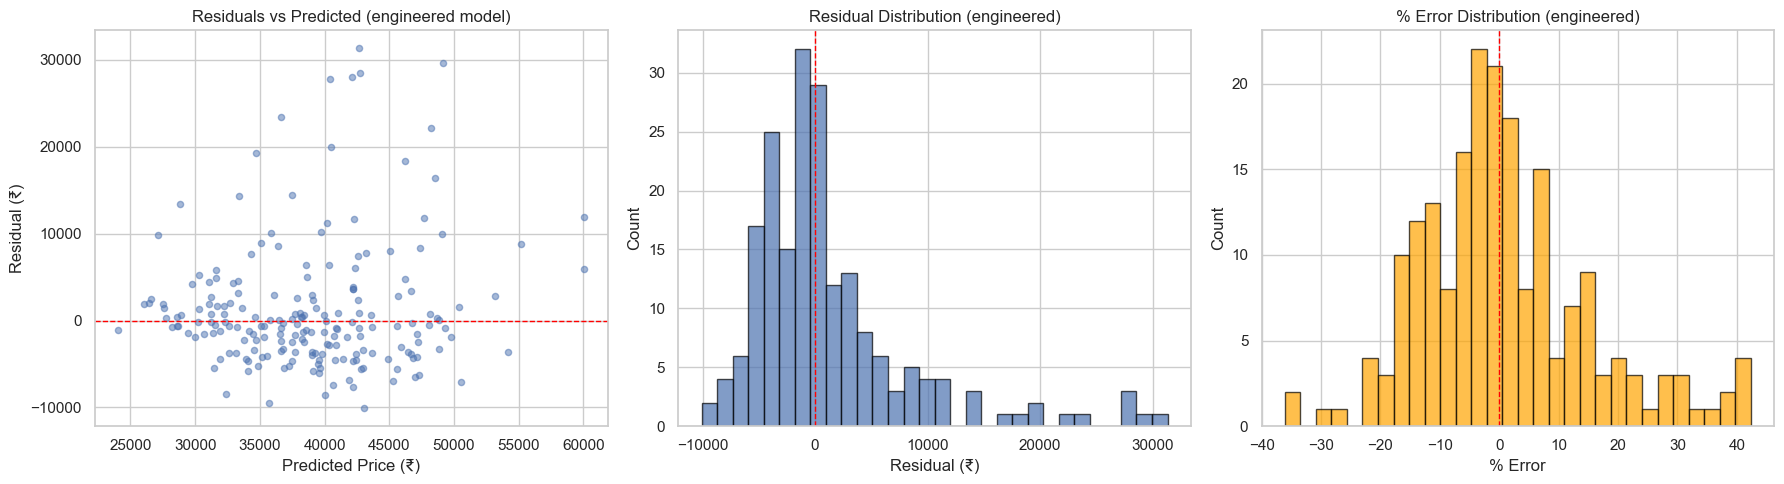

Top 10 worst predictions on test set (engineered model):
          brand  capacity  star_rating ac_type  inverter   actual     predicted  pct_error
937  Electrolux       1.5            5   Split         1  73990.0  42663.446846  42.338901
404    Motorola       2.0            3   Split         1  68199.0  40420.697266  40.731246
953      Voltas       1.5            5   Split         1  71179.0  42705.126006  40.003195
867          LG       1.0            5   Split         1  70138.0  42093.283936  39.985052
450          LG       1.0            3   Split         1  60055.0  36630.168779  39.005630
532          LG       1.5            4   Split         1  78799.0  49164.014519  37.608327
290      Daikin       1.0            3   Split         0  26251.0  35725.880840 -36.093409
453   Panasonic       1.0            3   Split         1  53900.0  34671.110679  35.675119
10        Haier       1.0            3   Split         1  23990.0  32409.704260 -35.096725
846     Carrier       1.5        

In [30]:
# ====================================================================
# Post-engineering residual check (rupee space, apples-to-apples with baseline)
# ====================================================================
# Same 3 plots + worst-10 table as the baseline diagnostic. The goal is
# to visually confirm whether the engineered features improved:
#   1. Heteroscedasticity (fan shape)
#   2. Long positive tail (under-prediction of expensive ACs)
#   3. % error distribution
#   4. Composition of the worst-predicted rows

test_residuals = y_test_true - y_test_pred
test_pct_error = (test_residuals / y_test_true) * 100

# Build diagnostic frame
diag = pd.DataFrame({
    'actual':    y_test_true.values,
    'predicted': y_test_pred,
    'residual':  test_residuals,
    'pct_error': test_pct_error,
})
diag.index = y_test_true.index
diag = diag.join(data[['brand', 'capacity', 'star_rating', 'ac_type', 'inverter']])

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test_pred, test_residuals, alpha=0.5, s=20)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Price (₹)')
axes[0].set_ylabel('Residual (₹)')
axes[0].set_title('Residuals vs Predicted (engineered model)')

axes[1].hist(test_residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual (₹)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution (engineered)')

axes[2].hist(test_pct_error, bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[2].axvline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('% Error')
axes[2].set_ylabel('Count')
axes[2].set_title('% Error Distribution (engineered)')

plt.tight_layout()
plt.show()

# --- Top 10 worst predictions ---
print("Top 10 worst predictions on test set (engineered model):")
worst = diag.reindex(diag['pct_error'].abs().nlargest(10).index)
print(worst[['brand', 'capacity', 'star_rating', 'ac_type', 'inverter', 'actual', 'predicted', 'pct_error']].to_string())


In [31]:
# ====================================================================
# Save engineered features for Stage 3
# ====================================================================
# Save the full data (raw + engineered) so Stage 3 can build pipelines
# on top of it. We save the full dataframe (not just features) so the
# next notebook has access to brand, capacity, etc. for preprocessing.

output_path = output_dir / 'ac_features.parquet'
data.to_parquet(output_path, index=False)

print(f"Saved {data.shape[0]} rows × {data.shape[1]} columns to:")
print(f"  {output_path}")
print()
print("Engineered columns added (5):")
print(f"  - log_price          (target for Stage 3+)")
print(f"  - smart_features     (0-3, replaces Wi-Fi+APP+Voice)")
print(f"  - age                (= 2026 - model_year, brand-median imputed)")
print(f"  - model_year_missing (1 if was missing, 0 otherwise)")
print(f"  - inverter_x_star    (inverter × star_rating interaction)")
print()
print("Stage 3 (model experiments) will read this parquet and:")
print("  1. Apply the same ColumnTransformer pipeline (one-hot brand, log target)")
print("  2. Try ridge, lasso, elasticnet, decision tree, random forest, xgboost")
print("  3. Compare all 7 models on the same train/test split")


Saved 994 rows × 28 columns to:
  D:\Study\data_science\underpriced-listing-predictor\data\04.features\ac_features.parquet

Engineered columns added (5):
  - log_price          (target for Stage 3+)
  - smart_features     (0-3, replaces Wi-Fi+APP+Voice)
  - age                (= 2026 - model_year, brand-median imputed)
  - model_year_missing (1 if was missing, 0 otherwise)
  - inverter_x_star    (inverter × star_rating interaction)

Stage 3 (model experiments) will read this parquet and:
  1. Apply the same ColumnTransformer pipeline (one-hot brand, log target)
  2. Try ridge, lasso, elasticnet, decision tree, random forest, xgboost
  3. Compare all 7 models on the same train/test split


## Stage 2 — Feature Engineering Conclusion

### What this notebook did
Applied 5 engineering targets to the cleaned dataset:
1. `log_price` — target transformation for heteroscedasticity
2. `smart_features = Wi-Fi + APP + Voice` — collapse 3 collinear flags
3. `age = 2026 − model_year` — brand-median imputation + depreciation signal
4. `model_year_missing` indicator
5. `inverter × star_rating` interaction

### Result
| Metric    | Baseline | Engineered | Lift   |
|-----------|----------|------------|--------|
| Test R²   | 0.471    | **0.483**  | +0.012 |
| Test MAE  | ₹5,255   | **₹4,754** | −₹501  |
| Test RMSE | ₹7,493   | ₹7,410     | −₹83   |
| Gap       | 0.043    | 0.057      | +0.014 |

### Key findings
1. **Brand target encoding was wrong for linear models** — smoothing=10 over-shrunk
   the brand signal. Reverted to one-hot brand (more flexible with 30 brands and
   ~33 rows per brand on average). The TargetEncoder import is unused but harmless.
2. **Engineering helped MAE more than R²** — typical errors dropped ₹501, but
   the brand × capacity variance is still uncaptured.
3. **8 of 10 worst-predicted rows are the same as baseline** — the brand ×
   capacity interaction is structural (Daikin 1.0T 3-star non-inverter at ₹26K,
   LG 1.0T 5-star inverter at ₹70K) and beyond what linear models can fix.
4. **Linear models are plateauing at R² ≈ 0.48.** The remaining gap to the
   0.80 deploy bar needs tree models' native handling of non-linear
   interactions, not more feature engineering.

### Stage 3 — what model experiments must do
1. Re-fit the same `LinearRegression` on engineered features (control)
2. Try Ridge, Lasso, ElasticNet — regularization may help (we added 4 features)
3. Try Decision Tree, Random Forest, XGBoost — non-linear models that handle
   brand × capacity interactions natively
4. Compare all 7 models on the same train/test split; pick best by R², RMSE, MAE
5. The 4 engineered features will help *all* models, but tree models will
   get the biggest lift — that's where we close the 0.32 R² gap to deploy bar.
